# Classifier Context Test

`services/forest_mask/cli.py` で追加された `anomaly_context` を確認するノートブック。

- `services/forest_mask/context.py` の `filter_components_by_surrounding_healthy` で、 `anomaly_compo` の各連結成分のうち「健全な森林に囲まれた小さめの成分」だけを残す。
- 道路 / 裸地 / 大きな開放地のような誤検出を抑制し、森林内の異常候補のみを残すのが目的。
- パラメータ ( `min_size` / `max_size` / `buffer_size` / `min_healthy_ratio` ) を振って挙動を確認する。

入力: `data/input/jpg/sample/sample_tree.jpg`

In [1]:
# プロジェクトルートで実行できるようにカレントを移動
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())

cwd: /home/mqsol/works/forest-analyzer


In [2]:
# モジュールリロードを有効化
%load_ext autoreload
%autoreload 2

In [3]:
# パラメータ (CLI に合わせる)
INPUT_PATH = Path("data/input/jpg/sample/sample_tree.jpg")

EXG_THRESHOLD = 10.0
SAT_TH = 80.0
LAB_A_TH = 125.0
ANOMALY_SAT_TH = 60.0
ANOMALY_VAL_TH = 170.0
TEXTURE_KERNEL = 5
TEXTURE_TH = 5.0

ANOMALY_CLOSING = 5
ANOMALY_OPENING = 3
HEALTHY_CLOSING = 7
HEALTHY_OPENING = 3
MIN_SIZE_COMPO = 300

# anomaly_context 用 (CLI の anomaly_context に揃える)
CTX_MIN_SIZE = 30
CTX_MAX_SIZE = 2000
CTX_BUFFER_SIZE = 15
CTX_MIN_HEALTHY_RATIO = 0.4

In [4]:
# 特徴量計算 -> 分類 -> モルフォロジー -> 連結成分 -> context filter
from services.common.image import load_rgb
from services.forest_mask.exg import calc_exg
from services.forest_mask.color import calc_hsv, calc_lab
from services.forest_mask.texture import calc_texture
from services.forest_mask.classifier import classify_forest_status
from services.forest_mask.morphology import apply_morphology
from services.forest_mask.components import remove_small_components
from services.forest_mask.overlay import create_mask_overlay
from services.forest_mask.context import filter_components_by_surrounding_healthy

rgb = load_rgb(INPUT_PATH)
exg = calc_exg(rgb)
hsv_h, hsv_s, hsv_v = calc_hsv(rgb)
lab_l, lab_a, lab_b = calc_lab(rgb)
texture = calc_texture(exg, TEXTURE_KERNEL)

healthy_mask, anomaly_mask, unknown_mask = classify_forest_status(
    exg=exg,
    s=hsv_s,
    v=hsv_v,
    lab_a=lab_a,
    texture=texture,
    exg_threshold=EXG_THRESHOLD,
    saturation_threshold=SAT_TH,
    lab_a_threshold=LAB_A_TH,
    anomaly_saturation_threshold=ANOMALY_SAT_TH,
    anomaly_value_threshold=ANOMALY_VAL_TH,
    texture_threshold=TEXTURE_TH,
)

anomaly_morph = apply_morphology(anomaly_mask, ANOMALY_CLOSING, ANOMALY_OPENING)
anomaly_compo = remove_small_components(anomaly_morph, min_size=MIN_SIZE_COMPO)
healthy_morph = apply_morphology(healthy_mask, HEALTHY_CLOSING, HEALTHY_OPENING)

anomaly_context = filter_components_by_surrounding_healthy(
    anomaly_mask=anomaly_compo,
    healthy_mask=healthy_morph,
    min_size=CTX_MIN_SIZE,
    max_size=CTX_MAX_SIZE,
    buffer_size=CTX_BUFFER_SIZE,
    min_healthy_ratio=CTX_MIN_HEALTHY_RATIO,
)

total = rgb.shape[0] * rgb.shape[1]
rows = [
    ("anomaly_compo", anomaly_compo),
    ("anomaly_context", anomaly_context),
    ("healthy_morph", healthy_morph),
]
for name, m in rows:
    pix = int(m.sum())
    print(f"{name:16s}: {pix:>10d} px  ({pix / total * 100:5.2f}%)")

anomaly_compo   :     368939 px  (11.74%)
anomaly_context :      10014 px  ( 0.32%)
healthy_morph   :     986417 px  (31.40%)


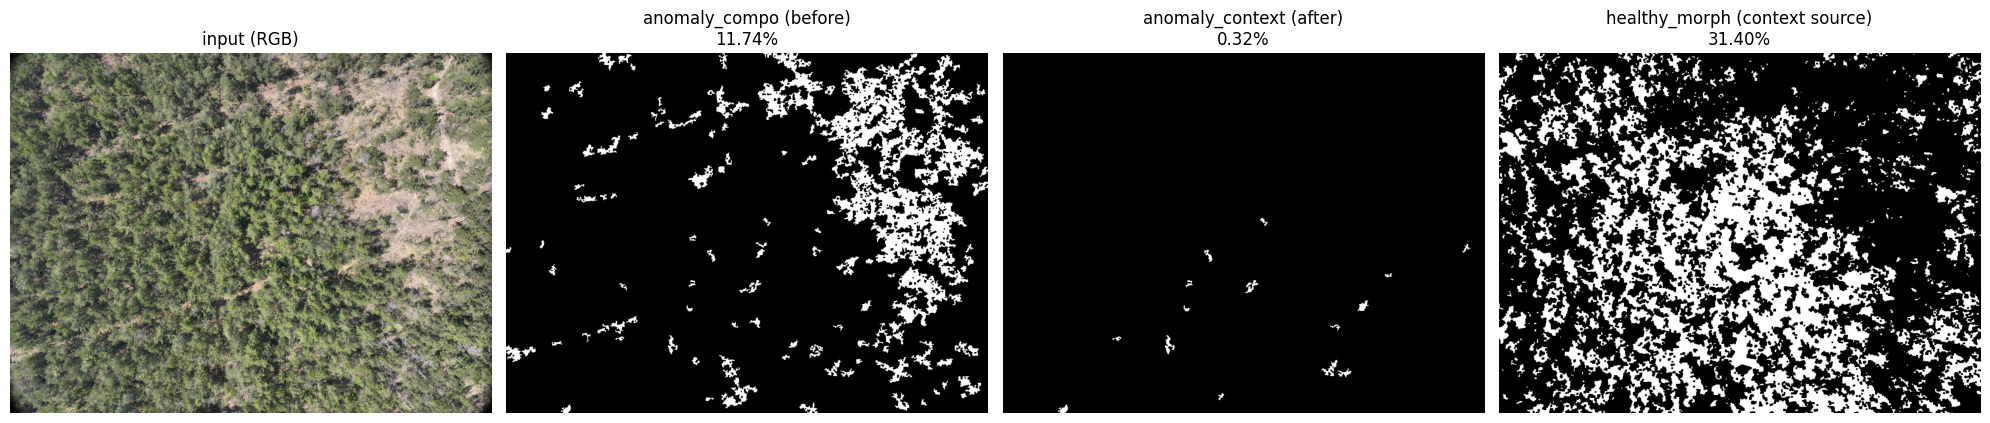

In [5]:
# 入力 / anomaly_compo / anomaly_context / healthy_morph を横並びで比較
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(rgb)
axes[0].set_title("input (RGB)")
axes[0].axis("off")

for ax, mask, name in [
    (axes[1], anomaly_compo, "anomaly_compo (before)"),
    (axes[2], anomaly_context, "anomaly_context (after)"),
    (axes[3], healthy_morph, "healthy_morph (context source)"),
]:
    ax.imshow(mask, cmap="gray", vmin=0, vmax=1)
    pix = int(mask.sum())
    ax.set_title(f"{name}\n{pix / total * 100:.2f}%")
    ax.axis("off")

plt.tight_layout()
plt.show()

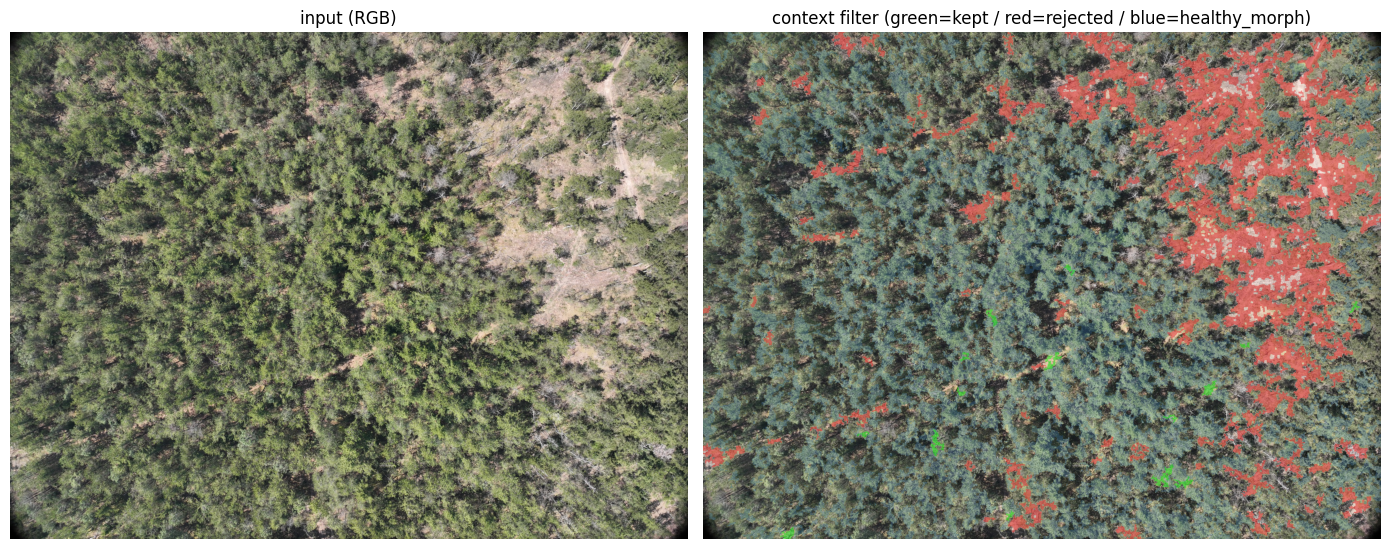

kept     :      10014 px  ( 0.32%)
rejected :     358925 px  (11.42%)


In [6]:
# context filter で残った/落とされた成分の可視化
#   kept     = 緑 (anomaly_context)
#   rejected = 赤 (anomaly_compo にあったが anomaly_context で落とされたもの)
#   healthy  = 薄い青 (周辺コンテキストとして使われた領域)
import numpy as np

ALPHA = 0.5
kept = anomaly_context
rejected = anomaly_compo & ~anomaly_context

overlay = rgb.astype(np.float32).copy()
overlay[healthy_morph] = (1 - 0.25) * overlay[healthy_morph] + 0.25 * np.array([80, 140, 220], dtype=np.float32)
overlay[kept] = (1 - ALPHA) * overlay[kept] + ALPHA * np.array([0, 220, 0], dtype=np.float32)
overlay[rejected] = (1 - ALPHA) * overlay[rejected] + ALPHA * np.array([220, 30, 30], dtype=np.float32)
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(rgb)
axes[0].set_title("input (RGB)")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title("context filter (green=kept / red=rejected / blue=healthy_morph)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"kept     : {int(kept.sum()):>10d} px  ({kept.sum() / total * 100:5.2f}%)")
print(f"rejected : {int(rejected.sum()):>10d} px  ({rejected.sum() / total * 100:5.2f}%)")

components: 122  (kept=15, rejected=107)


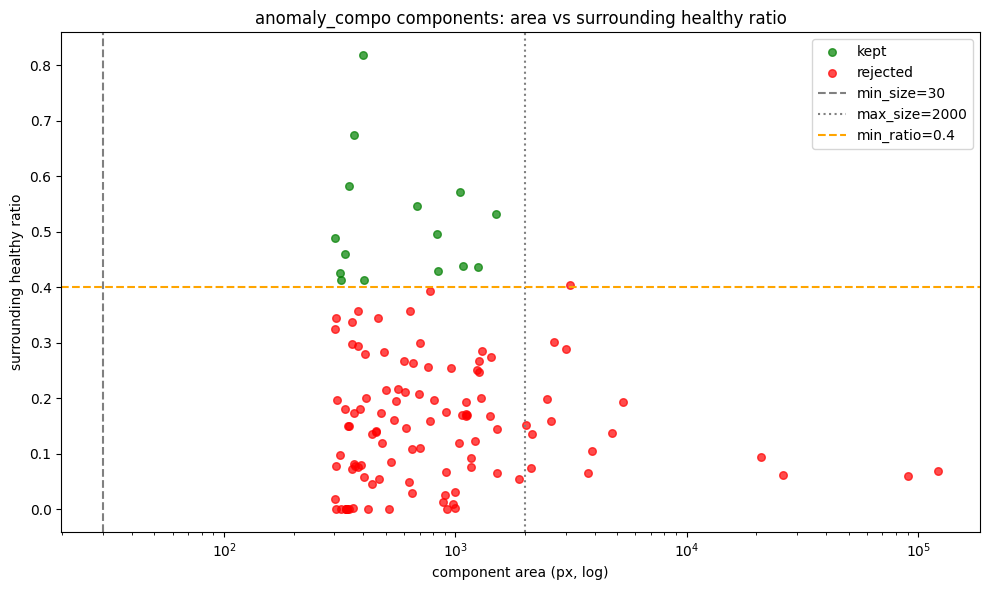

In [7]:
# 各 anomaly_compo 成分の (area, surrounding healthy_ratio) を可視化
#   filter 条件: min_size <= area <= max_size かつ healthy_ratio >= min_healthy_ratio
import cv2

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    anomaly_compo.astype(np.uint8),
    connectivity=8,
)

kernel = np.ones((CTX_BUFFER_SIZE, CTX_BUFFER_SIZE), np.uint8)
areas = []
ratios = []
kept_flags = []
for lab in range(1, num_labels):
    area = stats[lab, cv2.CC_STAT_AREA]
    component = (labels == lab)
    dilated = cv2.dilate(component.astype(np.uint8), kernel, iterations=1).astype(bool)
    surrounding = dilated & ~component
    s_area = np.count_nonzero(surrounding)
    ratio = float(np.count_nonzero(healthy_morph & surrounding)) / s_area if s_area > 0 else 0.0
    in_size = CTX_MIN_SIZE <= area <= CTX_MAX_SIZE
    in_ratio = ratio >= CTX_MIN_HEALTHY_RATIO
    areas.append(area)
    ratios.append(ratio)
    kept_flags.append(in_size and in_ratio)

areas = np.array(areas)
ratios = np.array(ratios)
kept_flags = np.array(kept_flags)

print(f"components: {len(areas)}  (kept={int(kept_flags.sum())}, rejected={int((~kept_flags).sum())})")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(areas[kept_flags], ratios[kept_flags], c="green", label="kept", alpha=0.7, s=30)
ax.scatter(areas[~kept_flags], ratios[~kept_flags], c="red", label="rejected", alpha=0.7, s=30)
ax.axvline(CTX_MIN_SIZE, color="gray", linestyle="--", label=f"min_size={CTX_MIN_SIZE}")
ax.axvline(CTX_MAX_SIZE, color="gray", linestyle=":", label=f"max_size={CTX_MAX_SIZE}")
ax.axhline(CTX_MIN_HEALTHY_RATIO, color="orange", linestyle="--", label=f"min_ratio={CTX_MIN_HEALTHY_RATIO}")
ax.set_xscale("log")
ax.set_xlabel("component area (px, log)")
ax.set_ylabel("surrounding healthy ratio")
ax.set_title("anomaly_compo components: area vs surrounding healthy ratio")
ax.legend()
plt.tight_layout()
plt.show()

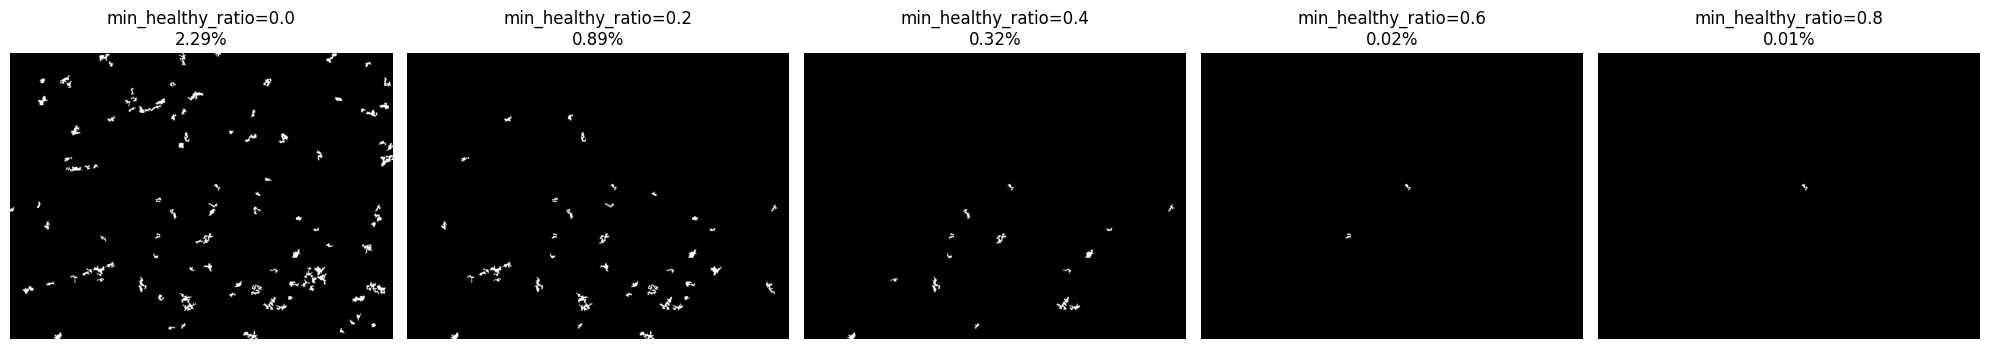

In [8]:
# min_healthy_ratio をスイープ
ratios_sweep = [0.0, 0.2, 0.4, 0.6, 0.8]

fig, axes = plt.subplots(1, len(ratios_sweep), figsize=(4 * len(ratios_sweep), 4))
for ax, r in zip(axes, ratios_sweep):
    m = filter_components_by_surrounding_healthy(
        anomaly_mask=anomaly_compo,
        healthy_mask=healthy_morph,
        min_size=CTX_MIN_SIZE,
        max_size=CTX_MAX_SIZE,
        buffer_size=CTX_BUFFER_SIZE,
        min_healthy_ratio=r,
    )
    pix = int(m.sum())
    ax.imshow(m, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"min_healthy_ratio={r}\n{pix / total * 100:.2f}%")
    ax.axis("off")
plt.tight_layout()
plt.show()

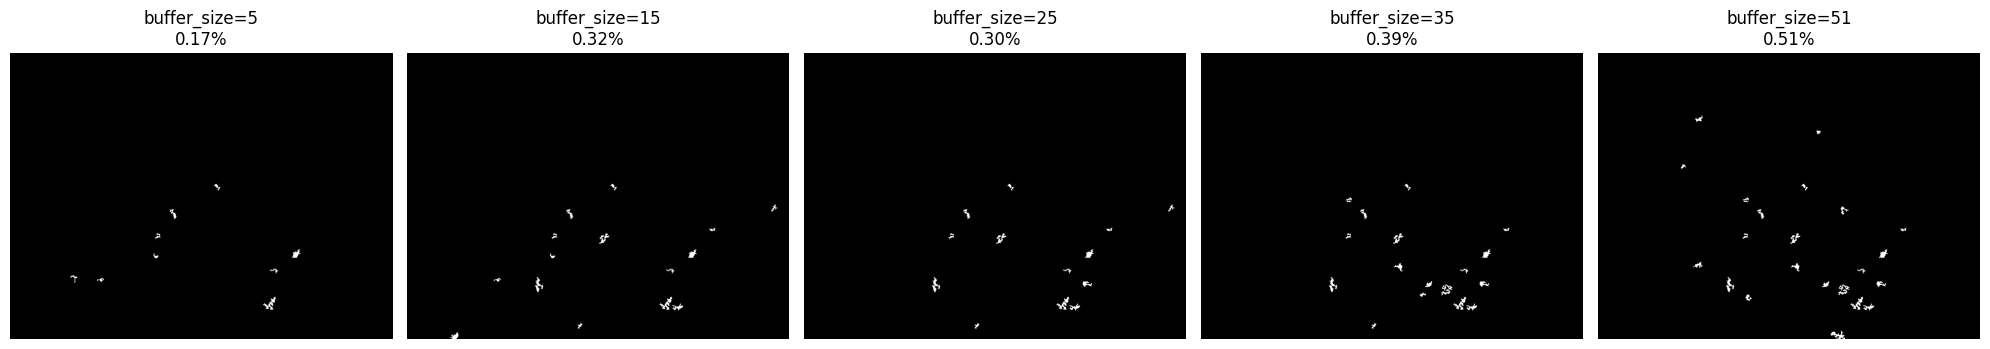

In [9]:
# buffer_size をスイープ
buffers = [5, 15, 25, 35, 51]

fig, axes = plt.subplots(1, len(buffers), figsize=(4 * len(buffers), 4))
for ax, b in zip(axes, buffers):
    m = filter_components_by_surrounding_healthy(
        anomaly_mask=anomaly_compo,
        healthy_mask=healthy_morph,
        min_size=CTX_MIN_SIZE,
        max_size=CTX_MAX_SIZE,
        buffer_size=b,
        min_healthy_ratio=CTX_MIN_HEALTHY_RATIO,
    )
    pix = int(m.sum())
    ax.imshow(m, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"buffer_size={b}\n{pix / total * 100:.2f}%")
    ax.axis("off")
plt.tight_layout()
plt.show()

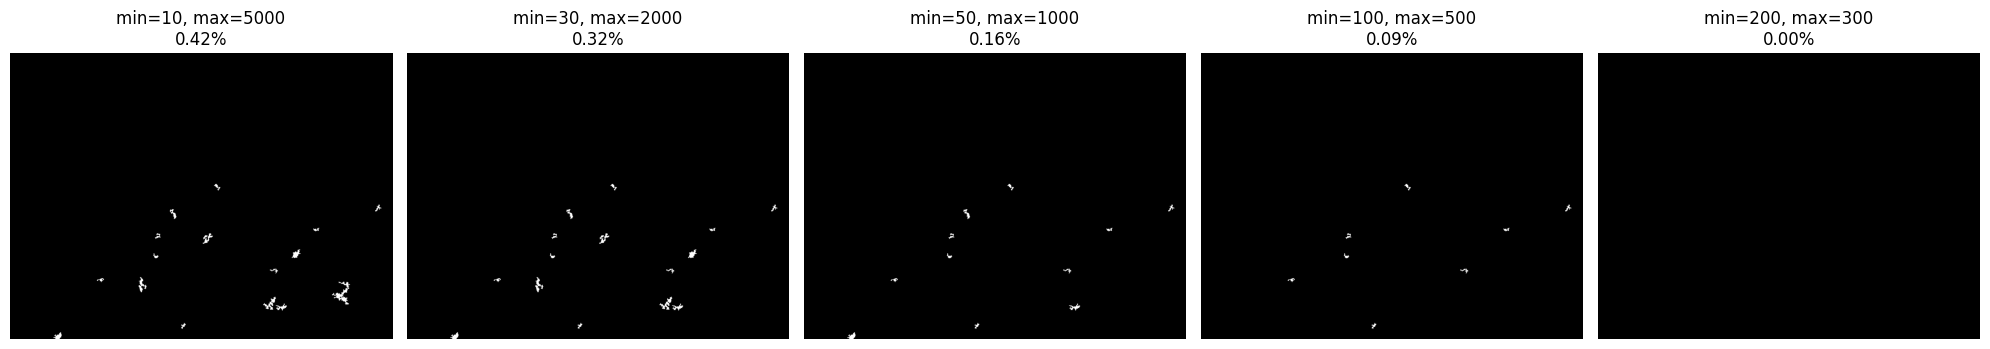

In [10]:
# (min_size, max_size) をスイープ
size_sets = [
    (10, 5000),
    (30, 2000),
    (50, 1000),
    (100, 500),
    (200, 300),
]

fig, axes = plt.subplots(1, len(size_sets), figsize=(4 * len(size_sets), 4))
for ax, (mn, mx) in zip(axes, size_sets):
    m = filter_components_by_surrounding_healthy(
        anomaly_mask=anomaly_compo,
        healthy_mask=healthy_morph,
        min_size=mn,
        max_size=mx,
        buffer_size=CTX_BUFFER_SIZE,
        min_healthy_ratio=CTX_MIN_HEALTHY_RATIO,
    )
    pix = int(m.sum())
    ax.imshow(m, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"min={mn}, max={mx}\n{pix / total * 100:.2f}%")
    ax.axis("off")
plt.tight_layout()
plt.show()

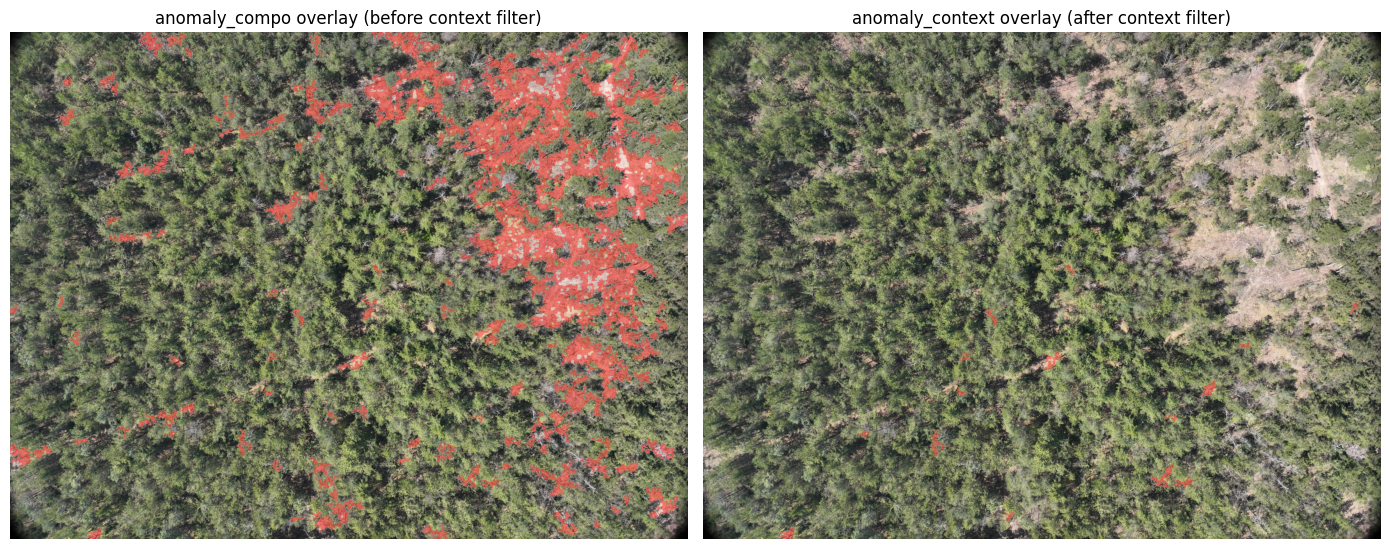

In [11]:
# 最終結果を元画像にオーバーレイ
context_overlay = create_mask_overlay(rgb, anomaly_context, color=(255, 0, 0), alpha=0.4)
compo_overlay = create_mask_overlay(rgb, anomaly_compo, color=(255, 0, 0), alpha=0.4)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(compo_overlay)
axes[0].set_title("anomaly_compo overlay (before context filter)")
axes[0].axis("off")
axes[1].imshow(context_overlay)
axes[1].set_title("anomaly_context overlay (after context filter)")
axes[1].axis("off")
plt.tight_layout()
plt.show()